### Improving the model 

In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Step 2: Reload the preprocessed data
data_preprocessed = pd.read_csv('/Users/arpitalonakadi/Downloads/employee_preprocessed_data.csv')
data_preprocessed.head()

,Reason_1,Reason_2,Reason_3,Reason_4,Month Value,Day of the Week,Transportation Expense,Distance to Work,Age,Daily Work Load Average,Body Mass Index,Education,Children,Pets,Absenteeism Time in Hours
0,0,0,0,1,7,1,289,36,33,239.554,30,0,2,1,4
1,0,0,0,0,7,1,118,13,50,239.554,31,0,1,0,0
2,0,0,0,1,7,2,179,51,38,239.554,31,0,0,0,2
3,1,0,0,0,7,3,279,5,39,239.554,24,0,2,0,4
4,0,0,0,1,7,3,289,36,33,239.554,30,0,2,1,2


In [2]:
# Step 3: Create binary target: 1 if absenteeism > median, else 0
targets = np.where(data_preprocessed['Absenteeism Time in Hours'] > 
                   data_preprocessed['Absenteeism Time in Hours'].median(), 1, 0)

# Step 4: Add target to the dataframe
data_preprocessed['Excessive Absenteeism'] = targets

dropping low impact features based on baseline model 

In [3]:
# Step 5: Drop columns that are not useful or had low impact
columns_to_drop = [
    'Absenteeism Time in Hours',  # target already created
    'Day of the Week',
    'Distance to Work',
    'Daily Work Load Average',
    'Age',
    'Education',
    'Pets'
]

data_model = data_preprocessed.drop(columns=columns_to_drop)
data_model.head()

,Reason_1,Reason_2,Reason_3,Reason_4,Month Value,Transportation Expense,Body Mass Index,Children,Excessive Absenteeism
0,0,0,0,1,7,289,30,2,1
1,0,0,0,0,7,118,31,1,0
2,0,0,0,1,7,179,31,0,0
3,1,0,0,0,7,279,24,2,1
4,0,0,0,1,7,289,30,2,0


In [4]:
# Step 6: Separate inputs and target
unscaled_inputs = data_model.drop(['Excessive Absenteeism'], axis=1)
target = data_model['Excessive Absenteeism']

In [5]:
# Step 7: Define which columns to exclude from scaling
columns_to_omit = ['Reason_1', 'Reason_2', 'Reason_3', 'Reason_4']
columns_to_scale = [col for col in unscaled_inputs.columns if col not in columns_to_omit]

# Step 8: Custom Scaler Class
from sklearn.base import BaseEstimator, TransformerMixin

class CustomScaler(BaseEstimator, TransformerMixin):
    def __init__(self, columns, copy=True, with_mean=True, with_std=True):
        self.scaler = StandardScaler(copy=copy, with_mean=with_mean, with_std=with_std)
        self.columns = columns
        self.mean_ = None
        self.var_ = None

    def fit(self, X, y=None):
        self.scaler.fit(X[self.columns], y)
        self.mean_ = np.mean(X[self.columns])
        self.var_ = np.var(X[self.columns])
        return self

    def transform(self, X, y=None, copy=None):
        init_col_order = X.columns
        X_scaled = pd.DataFrame(self.scaler.transform(X[self.columns]), columns=self.columns)
        X_not_scaled = X.loc[:, ~X.columns.isin(self.columns)]
        return pd.concat([X_not_scaled, X_scaled], axis=1)[init_col_order]

# Step 9: Initialize, fit and transform the scaler
absenteeism_scaler = CustomScaler(columns_to_scale)
absenteeism_scaler.fit(unscaled_inputs)
scaled_inputs = absenteeism_scaler.transform(unscaled_inputs)

/Users/arpitalonakadi/Library/Python/3.9/lib/python/site-packages/numpy/_core/fromnumeric.py:4006: FutureWarning: The behavior of DataFrame.var with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [6]:
# Step 10: Split the data
x_train, x_test, y_train, y_test = train_test_split(
    scaled_inputs, target, test_size=0.2, random_state=20
)

Building the logistic regression again

In [7]:
# Step 11: Train the model
reg = LogisticRegression()
reg.fit(x_train, y_train)

LogisticRegression()

In [8]:
# Step 12: Evaluate using classification report and ROC AUC
print("Classification Report:\n")
print(classification_report(y_test, reg.predict(x_test)))

print("ROC AUC:", roc_auc_score(y_test, reg.predict_proba(x_test)[:,1]))

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.73      0.72        74
           1       0.69      0.68      0.69        66

    accuracy                           0.71       140
   macro avg       0.71      0.71      0.71       140
weighted avg       0.71      0.71      0.71       140

ROC AUC: 0.7782555282555282


In [9]:
# Step 13: Analyze feature importance
feature_names = unscaled_inputs.columns.values
summary_table = pd.DataFrame(columns=['Feature name'], data=feature_names)
summary_table['Coefficient'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table['Odds_ratio'] = np.exp(summary_table['Coefficient'])

# Display final summary
summary_table.sort_values('Odds_ratio', ascending=False)

,Feature name,Coefficient,Odds_ratio
3,Reason_3,2.969897,19.489903
1,Reason_1,2.806598,16.553508
2,Reason_2,0.925536,2.523220
4,Reason_4,0.870101,2.387152
6,Transportation Expense,0.505109,1.657165
8,Children,0.354237,1.425093
7,Body Mass Index,0.230407,1.259112
5,Month Value,0.160193,1.173738
0,Intercept,-1.702707,0.182190


Here we see that dropping the features has not resulted in substantial improvement in the model. Thus, we will try to incorporate L1 and L2 regularization to check if it can enhance model performance by penalizing less informative features and improving generalization.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [11]:
# L1 Regularized Logistic Regression (Lasso)
reg_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
reg_l1.fit(x_train, y_train)

# Predict and Evaluate
print("=== L1 Regularization ===")
y_pred_l1 = reg_l1.predict(x_test)
print(classification_report(y_test, y_pred_l1))
print("ROC AUC:", roc_auc_score(y_test, reg_l1.predict_proba(x_test)[:, 1]))

=== L1 Regularization ===
              precision    recall  f1-score   support

           0       0.72      0.73      0.72        74
           1       0.69      0.68      0.69        66

    accuracy                           0.71       140
   macro avg       0.71      0.71      0.71       140
weighted avg       0.71      0.71      0.71       140

ROC AUC: 0.7862407862407863


In [12]:
# L2 Regularized Logistic Regression (Ridge)
reg_l2 = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)
reg_l2.fit(x_train, y_train)

# Predict and Evaluate
print("=== L2 Regularization ===")
y_pred_l2 = reg_l2.predict(x_test)
print(classification_report(y_test, y_pred_l2))
print("ROC AUC:", roc_auc_score(y_test, reg_l2.predict_proba(x_test)[:, 1]))

=== L2 Regularization ===
              precision    recall  f1-score   support

           0       0.72      0.73      0.72        74
           1       0.69      0.68      0.69        66

    accuracy                           0.71       140
   macro avg       0.71      0.71      0.71       140
weighted avg       0.71      0.71      0.71       140

ROC AUC: 0.7774365274365275


In [13]:
# Coefficients comparison
print("L1 Coefficients:")
print(reg_l1.coef_)

print("\nL2 Coefficients:")
print(reg_l2.coef_)

L1 Coefficients:
[[3.48730959 1.45717342 3.85153456 1.45919422 0.16395547 0.53066685
  0.24371093 0.36452086]]

L2 Coefficients:
[[2.63085428 0.82758061 2.80951967 0.69445827 0.15673805 0.49967373
  0.22809164 0.34907734]]


- Both L1 and L2 regularization did not significantly improve the baseline logistic regression model.
- This is expected because:
  - The dataset does not have a heavy class imbalance.
  - There are no strong signs of overfitting.
- Therefore, logistic regression performance is unlikely to improve much further with regularization.
- However, from a business perspective, our goal is to identify people who are most likely to be excessively absent.
- To support this goal, we will focus on selecting the best threshold value.
- We aim to strike a balance between recall and precision.
- The objective is to improve recall to better identify employees who may be frequently absent.

In [15]:
y_proba = reg.predict_proba(x_test)[:, 1]  # Probabilities for class 1

In [16]:
from sklearn.metrics import classification_report, roc_auc_score

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    print(f"\n=== Threshold: {threshold} ===")
    y_pred_thresh = (y_proba >= threshold).astype(int)
    print(classification_report(y_test, y_pred_thresh))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))


=== Threshold: 0.3 ===
              precision    recall  f1-score   support

           0       0.83      0.58      0.68        74
           1       0.65      0.86      0.74        66

    accuracy                           0.71       140
   macro avg       0.74      0.72      0.71       140
weighted avg       0.74      0.71      0.71       140

ROC AUC: 0.7782555282555282

=== Threshold: 0.4 ===
              precision    recall  f1-score   support

           0       0.78      0.66      0.72        74
           1       0.68      0.79      0.73        66

    accuracy                           0.72       140
   macro avg       0.73      0.73      0.72       140
weighted avg       0.73      0.72      0.72       140

ROC AUC: 0.7782555282555282

=== Threshold: 0.5 ===
              precision    recall  f1-score   support

           0       0.72      0.73      0.72        74
           1       0.69      0.68      0.69        66

    accuracy                           0.71       140


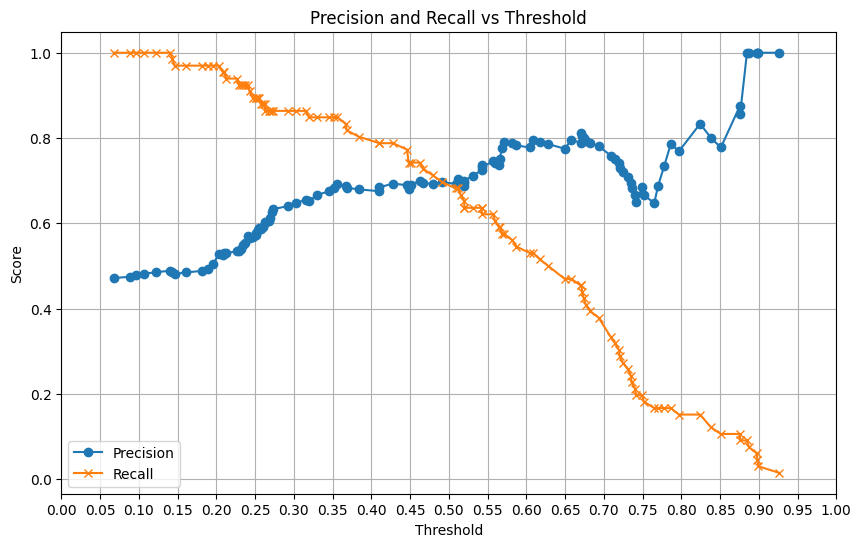

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Get predicted probabilities
y_scores = reg.predict_proba(x_test)[:, 1]

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Plot precision and recall
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', marker='o')
plt.plot(thresholds, recall[:-1], label='Recall', marker='x')

# Add labels, grid, title
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)

# Add more x-axis ticks
plt.xticks(np.arange(0.0, 1.05, 0.05))

plt.show()

- Based on the threshold analysis, setting the threshold to approximately **0.42** yields the same precision as the baseline model.
- However, it offers a **slightly higher recall**, allowing us to better identify employees likely to be excessively absent.
- Therefore, we will select **0.42** as our optimal threshold and finalize the model using this value.